In [1]:
import geoutils as gu
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xdem

from rasterio.mask import mask
import geopandas as gpd

from rasterio.windows import from_bounds

from rasterio.plot import show

import numpy.ma as ma
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [ ]:
dem_2021 = xdem.DEM(r"C:\Users\WilsonSIRL5-MCY-E113\Desktop\Catalyst June 2023\Reference\ARCTICDEMmerged_dem.tif")
print("Reference Coordinate Reference: " + str(dem_2021.crs))
print("Nodata vale: " + str(dem_2021.nodata))

dem_1960 = xdem.DEM(r"C:\Users\WilsonSIRL5-MCY-E113\Desktop\Catalyst June 2023\ANPDEM4.tif")

print("1960 DEM Coordinate Reference: " + str(dem_1960.crs))
print("Nodata vale: " + str(dem_1960.nodata))

plt_extent = [
    dem_1960.bounds.left,
    dem_1960.bounds.right,
    dem_1960.bounds.bottom,
    dem_1960.bounds.top,
]

Reference Coordinate Reference: EPSG:3413
Nodata vale: -9999.0
1960 DEM Coordinate Reference: EPSG:32620
Nodata vale: None


c:\Users\WilsonSIRL5-MCY-E113\miniconda3\envs\xdem\Lib\site-packages\geoutils\raster\raster.py:2782: UserWarning: Only nodata is different, consider using the 'set_nodata()' method instead'                    ' -> returning self (not a copy!)
  warnings.warn(


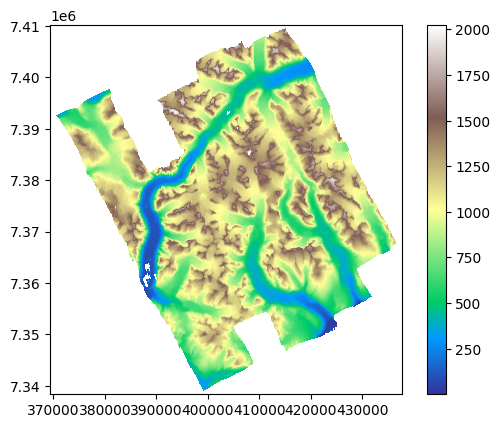

Dem_to_be_aligned Coordinate: EPSG:32620
Nodata value: nan


(4.0, 4.0)

In [3]:
dem_to_be_aligned = dem_1960.reproject(res=(4, 4))

dem_to_be_aligned.set_nodata(np.nan) 
dem_to_be_aligned.data[dem_to_be_aligned.data == 0] = np.nan
dem_to_be_aligned.data[dem_to_be_aligned.data < 0] = np.nan

plt.imshow(dem_to_be_aligned.data.squeeze(), cmap='terrain', extent=plt_extent)
plt.colorbar()
plt.show()

print("Dem_to_be_aligned Coordinate: " + str(dem_to_be_aligned.crs))
print("Nodata value: " + str(dem_to_be_aligned.nodata))
dem_to_be_aligned.res

In [5]:
# Calculate the area covered by dem_to_be_aligned in square kilometers
pixel_area_km2 = (dem_to_be_aligned.res[0] * dem_to_be_aligned.res[1]) / 1e6  # Area of one pixel in km^2
num_valid_pixels = np.sum(~np.isnan(dem_to_be_aligned.data))  # Number of valid (non-NaN) pixels
total_area_km2 = pixel_area_km2 * num_valid_pixels  # Total area covered in km^2

print(f"Total area covered by dem_to_be_aligned: {total_area_km2:.2f} square kilometers")

Total area covered by dem_to_be_aligned: 2473.57 square kilometers


In [ ]:
dem_to_be_aligned

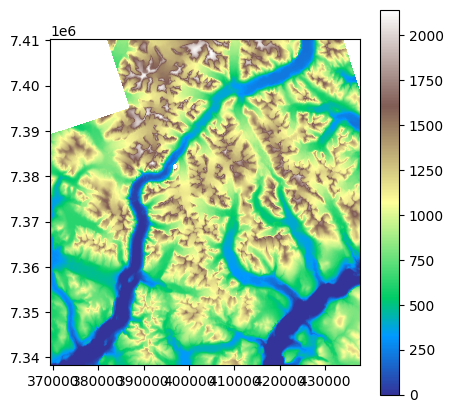

Reference Coordinate Reference: EPSG:32620
Nodata vale: -9999.0


(4.0, 4.0)

In [27]:
reference_dem = xdem.DEM(dem_2021).reproject(dem_to_be_aligned, resampling='bilinear')

plt.figure(figsize=(5, 5))
plt.imshow(reference_dem.data.squeeze(), cmap='terrain', extent=plt_extent)
plt.colorbar()
plt.show()

print("Reference Coordinate Reference: " + str(reference_dem.crs))
print("Nodata vale: " + str(reference_dem.nodata))
reference_dem.res

In [28]:
glacier_outlines = gu.Vector(r"D:\All_outline\ANP1960Shapefile.shp")
print("Outline CRS: " + str(glacier_outlines.crs))

glacier_outlines = glacier_outlines.to_crs(reference_dem.crs)
print("Reproject Outline CRS: " + str(glacier_outlines.crs))

Outline CRS: EPSG:4326
Reproject Outline CRS: PROJCS["WGS 84 / UTM zone 20N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-63],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32620"]]


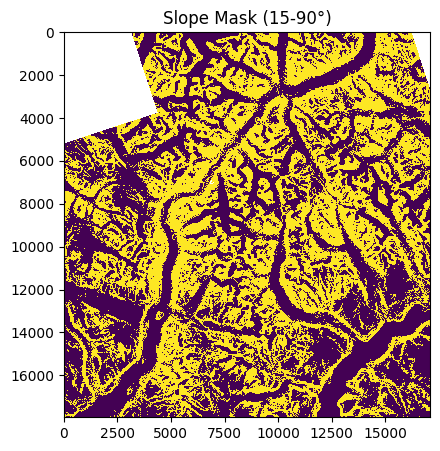

In [29]:
# Calculate slope
slope = xdem.terrain.slope(reference_dem)

# Create masks for slopes
slope_combined_mask = (slope.data > 15) & (slope.data <= 90) 

plt.figure(figsize=(5, 5))
plt.imshow(slope_combined_mask, interpolation='none')
plt.title("Slope Mask (15-90°)")
plt.show()

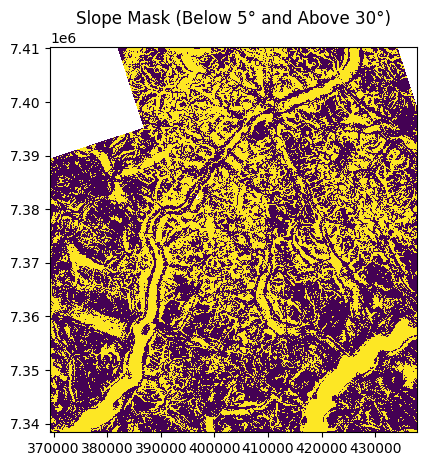

In [ ]:
# Calculate slope
slope = xdem.terrain.slope(reference_dem)

# Create masks for slopes below 10 degrees and over 30 degrees
mask_below_5 = slope.data < 5
mask_above_30 = slope.data > 30

# Combine the masks
slope_combined_mask = mask_below_5 | mask_above_30

# Plot the mask for slopes 
plt.figure(figsize=(5, 5))
plt.imshow(slope_combined_mask, interpolation='none', extent=plt_extent)
plt.title("Slope Mask (Below 5° and Above 30°)")
plt.show()

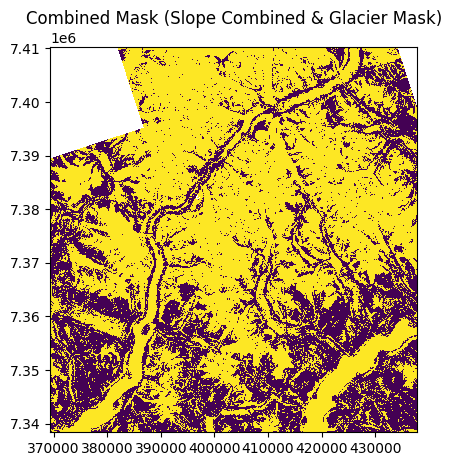

In [31]:
glacier_mask = glacier_outlines.create_mask(reference_dem)
combined_mask = slope_combined_mask + glacier_mask.data

plt.figure(figsize=(5, 5))
plt.imshow(combined_mask, interpolation='none', extent=plt_extent)
plt.title("Combined Mask (Slope Combined & Glacier Mask)")
plt.show()

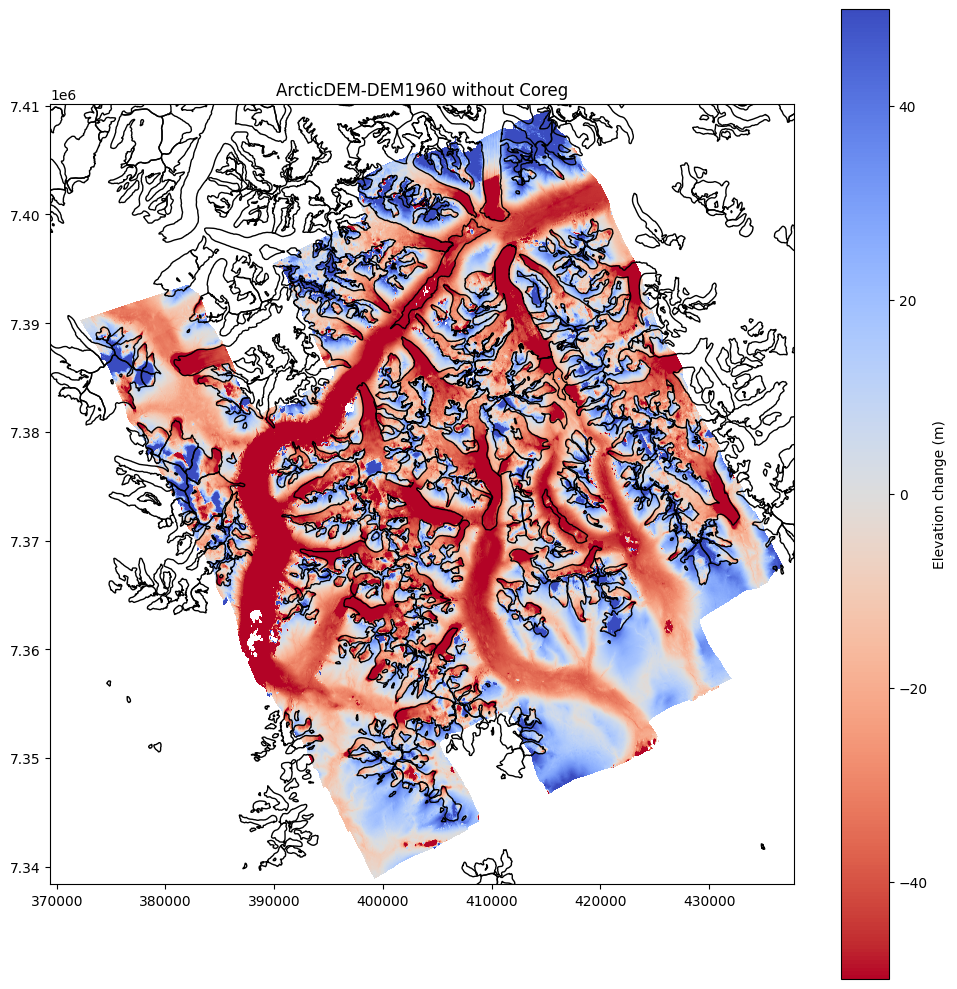

In [32]:
ddem_per = reference_dem - dem_to_be_aligned

plt.figure(figsize=(10, 10))
ax = plt.subplot(111)
glacier_outlines.ds.plot(ax=ax, facecolor='none', edgecolor='k', zorder=2)
plt.imshow(ddem_per.data, cmap='coolwarm_r', vmin=-50, vmax=50, zorder=1, extent=plt_extent)
plt.colorbar(label='Elevation change (m)')
ax.set_title('ArcticDEM-DEM1960 without Coreg')
plt.tight_layout()
plt.show()

In [33]:
# Copy the elevation difference DEM to avoid modifying the original
mean_dem = ddem_per.copy()

mean_dem.data[combined_mask] = np.nan

# Calculate the mean, median, standard deviation, and NMAD of the non-masked terrain
mean_elevation = np.nanmean(mean_dem.data)
median_elevation = ma.median(ma.masked_invalid(mean_dem.data))
std_dev_elevation = np.nanstd(mean_dem.data)
NMAD = xdem.spatialstats.nmad(mean_dem.data)  

print(f"Mean Elevation: {mean_elevation:.2f}")
print(f"Median Elevation: {median_elevation:.2f}")
print(f"Standard Deviation of Elevation: {std_dev_elevation:.2f}")
print(f"NMAD Elevation: {NMAD:.2f}")

Mean Elevation: -10.06
Median Elevation: -7.07
Standard Deviation of Elevation: 29.65
NMAD Elevation: 28.69


# Co Reg

In [37]:
nuth_kaab = xdem.coreg.NuthKaab()
nuth_kaab.fit(reference_dem, dem_to_be_aligned, inlier_mask=~combined_mask)
corrected_dem = nuth_kaab.apply(dem_to_be_aligned)

# Retrieve the parameters
params = nuth_kaab.meta
params

{'inputs': {'random': {'subsample': 500000.0, 'random_state': None},
  'fitorbin': {'fit_or_bin': 'bin_and_fit',
   'fit_func': <function xdem.coreg.affine._nuth_kaab_fit_func(xx: 'NDArrayf', *params: 'tuple[float, float, float]') -> 'NDArrayf'>,
   'fit_optimizer': <function scipy.optimize._minpack_py.curve_fit(f, xdata, ydata, p0=None, sigma=None, absolute_sigma=False, check_finite=None, bounds=(-inf, inf), method=None, jac=None, *, full_output=False, nan_policy=None, **kwargs)>,
   'bin_sizes': 72,
   'bin_statistic': <function nanmedian at 0x0000021775BD3C70>,
   'nd': 1,
   'bias_var_names': ['aspect']},
  'iterative': {'max_iterations': 10, 'tolerance': 0.001},
  'specific': {},
  'affine': {}},
 'outputs': {'affine': {'shift_x': 2.2749481128892515,
   'shift_y': -9.1378867820847,
   'shift_z': -0.6392671600434596},
  'random': {'subsample_final': 500000}}}

In [38]:
ddem_cont = reference_dem - corrected_dem 

# Copy the elevation difference DEM to avoid modifying the original
mean_dem = ddem_cont.copy()

mean_dem.data[combined_mask] = np.nan

# Calculate the mean, median, standard deviation, and NMAD of the non-masked terrain
mean_elevation = np.nanmean(mean_dem.data) 
median_elevation = ma.median(ma.masked_invalid(mean_dem.data))
std_dev_elevation = np.nanstd(mean_dem.data)
NMAD = xdem.spatialstats.nmad(mean_dem.data)  

print(f"Mean Elevation: {mean_elevation:.2f}")
print(f"Median Elevation: {median_elevation:.2f}")
print(f"Standard Deviation of Elevation: {std_dev_elevation:.2f}")
print(f"NMAD Elevation: {NMAD:.2f}")

Mean Elevation: -0.02
Median Elevation: 0.02
Standard Deviation of Elevation: 11.23
NMAD Elevation: 13.36


In [39]:
Deramp = xdem.coreg.Deramp(poly_order=2)
Deramp.fit(reference_dem, corrected_dem, inlier_mask=~combined_mask)
corrected_dem = Deramp.apply(corrected_dem)     

# Retrieve the parameters
params = Deramp.meta
params  

{'inputs': {'random': {'subsample': 500000.0, 'random_state': None},
  'fitorbin': {'fit_func': <function xdem.fit.polynomial_2d(xx: 'tuple[NDArrayf, NDArrayf]', *params: 'NDArrayf') -> 'NDArrayf'>,
   'fit_optimizer': <function scipy.optimize._minpack_py.curve_fit(f, xdata, ydata, p0=None, sigma=None, absolute_sigma=False, check_finite=None, bounds=(-inf, inf), method=None, jac=None, *, full_output=False, nan_policy=None, **kwargs)>,
   'bias_var_names': ['xx', 'yy'],
   'fit_or_bin': 'fit',
   'nd': 2},
  'iterative': {},
  'specific': {'poly_order': 2},
  'affine': {}},
 'outputs': {'random': {'subsample_final': 500000},
  'fitorbin': {'fit_perr': array([7.33771229e-02, 1.80932871e-05, 1.00778063e-09, 1.63826188e-05,
          3.89791934e-09, 2.15348297e-13, 9.06576037e-10, 2.05494530e-13,
          1.11495214e-17]),
   'fit_params': array([-1.78060074e+01,  4.78647389e-03, -3.86737343e-07,  4.96140036e-03,
          -1.46436090e-06,  1.04409942e-10, -2.65910599e-07,  7.42796759e-11

In [40]:
ddem_cont = reference_dem - corrected_dem 

# Copy the elevation difference DEM to avoid modifying the original
mean_dem = ddem_cont.copy()

mean_dem.data[combined_mask] = np.nan

# Calculate the mean, median, standard deviation, and NMAD of the non-masked terrain
mean_elevation = np.nanmean(mean_dem.data)
median_elevation = ma.median(ma.masked_invalid(mean_dem.data))
std_dev_elevation = np.nanstd(mean_dem.data)
NMAD = xdem.spatialstats.nmad(mean_dem.data)  

print(f"Mean Elevation: {mean_elevation:.2f}")
print(f"Median Elevation: {median_elevation:.2f}")
print(f"Standard Deviation of Elevation: {std_dev_elevation:.2f}")
print(f"NMAD Elevation: {NMAD:.2f}")

Mean Elevation: 0.01
Median Elevation: -0.05
Standard Deviation of Elevation: 10.66
NMAD Elevation: 12.27


In [41]:
vshift = xdem.coreg.VerticalShift()
vshift.fit(reference_dem, corrected_dem, inlier_mask=~combined_mask)
corrected_dem = vshift.apply(corrected_dem)

# Retrieve the parameters
params = vshift.meta
params

{'inputs': {'random': {'subsample': 1.0},
  'fitorbin': {},
  'iterative': {},
  'specific': {},
  'affine': {'vshift_reduc_func': <function median at 0x0000021775BD0D70>}},
 'outputs': {'random': {'subsample_final': 24375717},
  'affine': {'shift_z': -0.0491943359375}}}

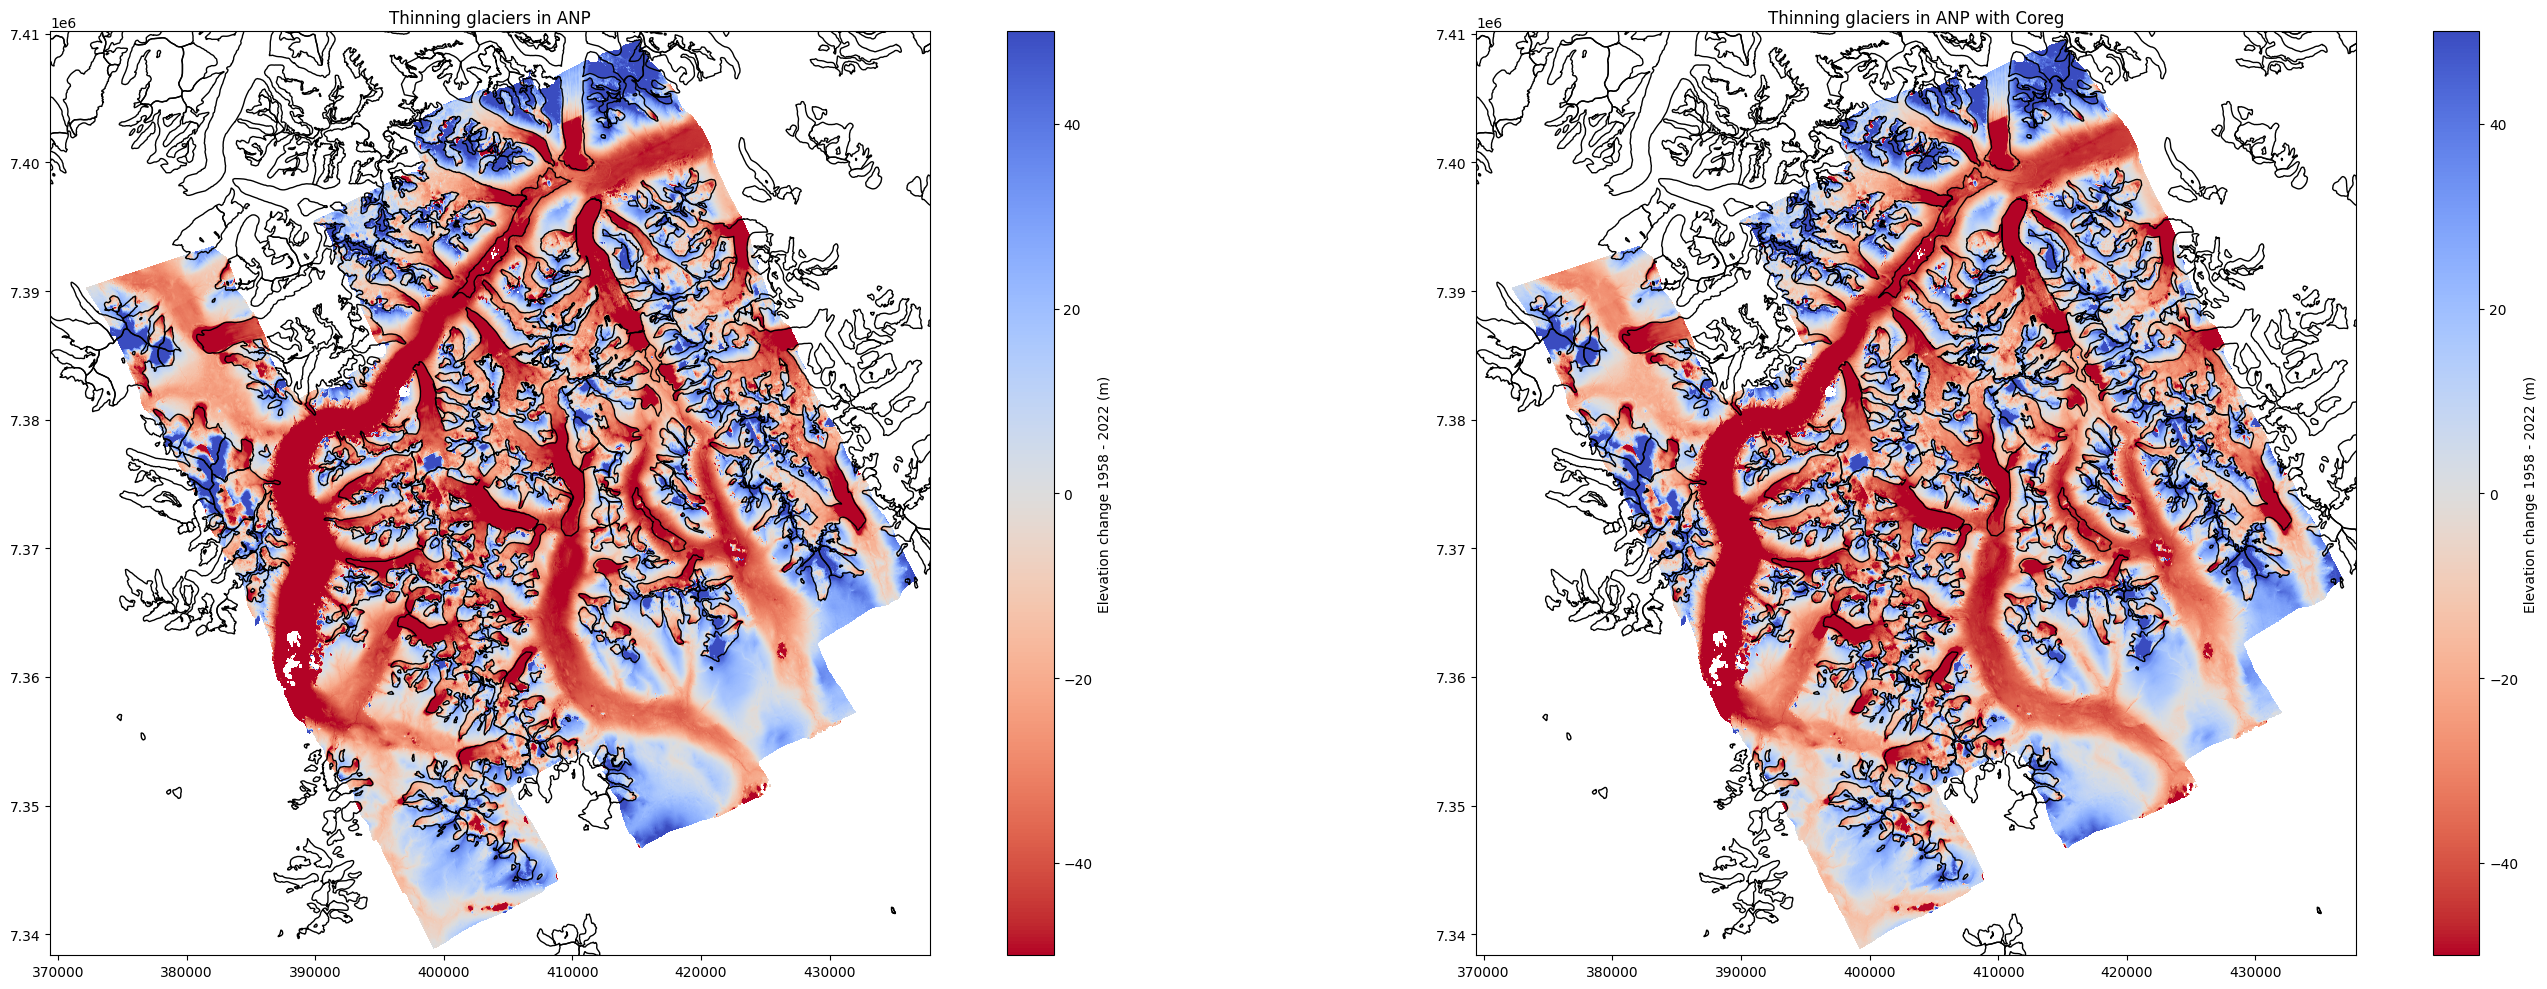

In [42]:
ddem_post = reference_dem - corrected_dem
fig, axs = plt.subplots(1,2, figsize=(30, 10))

# First plot
glacier_outlines.ds.plot(ax=axs[0], facecolor='none', edgecolor='k', zorder=2)
im1 = axs[0].imshow(ddem_per.data, cmap='coolwarm_r', vmin=-50, vmax=50, zorder=1, extent=plt_extent)
cbar1 = fig.colorbar(im1, ax=axs[0], label='Elevation change 1958 - 2022 (m)')
axs[0].set_title('Thinning glaciers in ANP')

# Second plot
glacier_outlines.ds.plot(ax=axs[1], facecolor='none', edgecolor='k', zorder=2)
im2 = axs[1].imshow(ddem_post.data, cmap='coolwarm_r', vmin=-50, vmax=50, zorder=1, extent=plt_extent)
cbar2 = fig.colorbar(im2, ax=axs[1], label='Elevation change 1958 - 2022 (m)')
axs[1].set_title('Thinning glaciers in ANP with Coreg')

plt.tight_layout()
plt.show()

C:\Users\WilsonSIRL5-MCY-E113\AppData\Local\Temp\ipykernel_27476\221376819.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


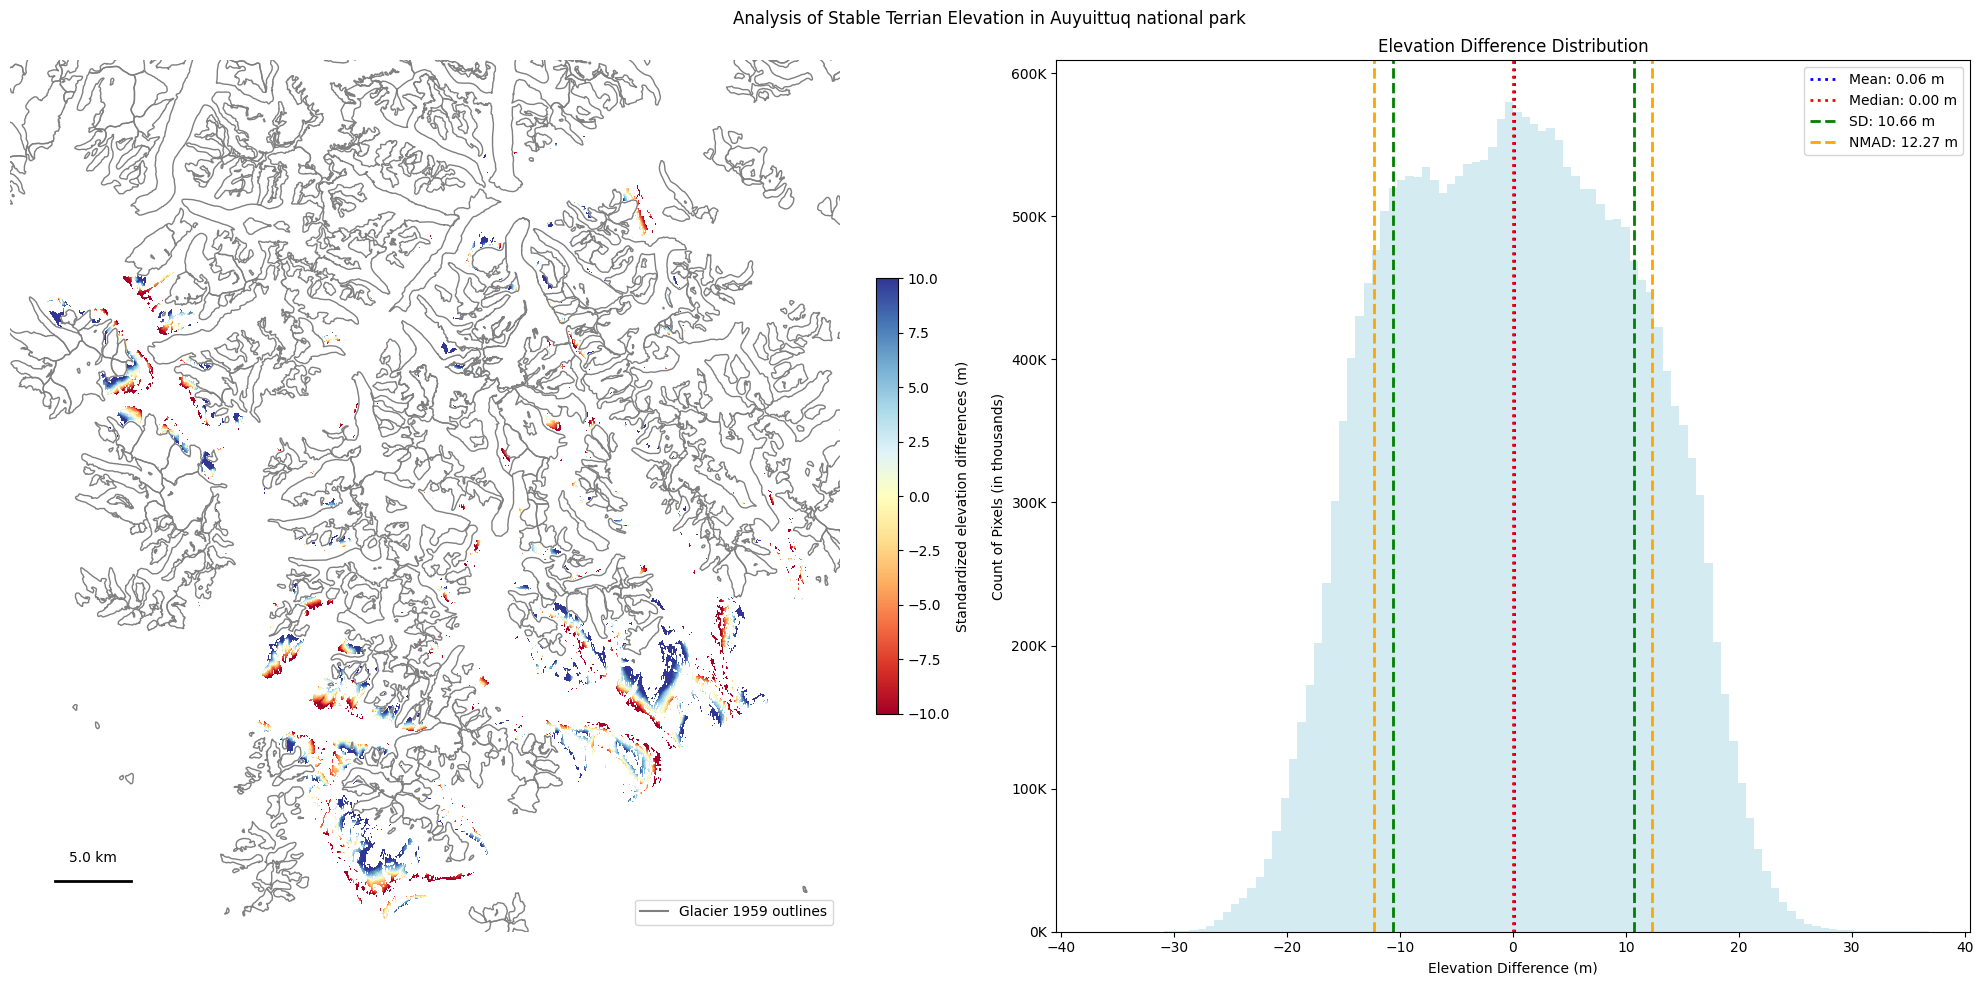

In [43]:
# Copy the elevation difference DEM to avoid modifying the original
mean_dem = ddem_post.copy()

mean_dem.data[combined_mask] = np.nan

mean_dem_float = mean_dem.astype(np.float64)

mean_elevation = np.nanmean(mean_dem.data)
median_elevation = ma.median(ma.masked_invalid(mean_dem.data))
std_dev = np.nanstd(mean_dem.data)
NMAD = xdem.spatialstats.nmad(mean_dem.data)  

elevation_data = mean_dem.data.compressed()
outlier_mask = np.abs(elevation_data - median_elevation) < 3 * NMAD
elevation_data_cleaned = elevation_data[outlier_mask]

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.axis('off')
glacier_outlines.ds.plot(ax=ax1, fc="none", ec="tab:gray", zorder=2)
ax1.plot([], [], color="tab:gray", label="Glacier 1959 outlines")

aspect = mean_dem_float.shape[0] / mean_dem_float.shape[1] * \
         (plt_extent[1] - plt_extent[0]) / (plt_extent[3] - plt_extent[2])

im = ax1.imshow(mean_dem_float.data, cmap="RdYlBu", vmin=-10, vmax=10, extent=plt_extent, aspect=aspect)

cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, shrink=0.5)
cbar.set_label("Standardized elevation differences (m)")
ax1.legend(loc="lower right")

# Adding a scale bar as an inset in the first subplot
scalebar_length = 5000  # Define length of the scale bar in meters (5 km)
scalebar_inset = inset_axes(ax1, width="10%", height="2%", loc="lower left", borderpad=3)
scalebar_inset.plot([0, scalebar_length], [0, 0], color='black', linewidth=2, zorder=3)
scalebar_inset.text(scalebar_length / 2, 0.1, f"{scalebar_length / 1000} km", ha='center', va='bottom', zorder=3)
scalebar_inset.axis('off')
ax1.legend(loc="lower right", fontsize=10)  

# Second subplot for the histogram
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: "{:,}K".format(int(x/1000))))
ax2.hist(elevation_data_cleaned, bins=100, color='lightblue', alpha=0.5)
ax2.axvline(mean_elevation, color='blue', linestyle='dotted', linewidth=2, label=f'Mean: {mean_elevation:.2f} m')
ax2.axvline(median_elevation, color='red', linestyle='dotted', linewidth=2, label=f'Median: {median_elevation:.2f} m')
ax2.axvline(mean_elevation + std_dev, color='green', linestyle='dashed', linewidth=2, label=f'SD: {std_dev:.2f} m')
ax2.axvline(mean_elevation - std_dev, color='green', linestyle='dashed', linewidth=2)
ax2.axvline(median_elevation + NMAD, color='orange', linestyle='dashed', linewidth=2, label=f'NMAD: {NMAD:.2f} m')
ax2.axvline(median_elevation - NMAD, color='orange', linestyle='dashed', linewidth=2)

ax2.set_xlabel('Elevation Difference (m)')
ax2.set_ylabel('Count of Pixels (in thousands)')
ax2.legend()
ax2.set_title('Elevation Difference Distribution')

# General title for the entire figure
plt.suptitle('Analysis of Stable Terrian Elevation in Auyuittuq national park')
plt.tight_layout()
plt.show()

In [44]:
ddem_post.save("D:\ANPDEM\ANPDEMcoreg_ddempostNOV024.tif")

In [45]:
dh = xdem.DEM(ddem_post)
ref_dem = xdem.DEM(reference_dem)
glacier_outlines = glacier_outlines.to_crs(dh.crs)

## Empirical variogram and plot

In [46]:
list_models=["Spherical", "Spherical"]

(
    df_empirical_variogram,
    df_model_params,
    spatial_corr_function,
) = xdem.spatialstats.infer_spatial_correlation_from_stable(
    dvalues=dh, list_models=list_models, unstable_mask=glacier_outlines
)

c:\Users\WilsonSIRL5-MCY-E113\miniconda3\envs\xdem\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [47]:
df_model_params

,model,range,psill
0,spherical,25.204694,756.926310
0,spherical,92681.900024,596.726112


In [48]:
for spatial_lag in [0, 100, 1000, 10000, 30000]:
    print(
        "Errors are correlated at {:.1f}% for a {:,.0f} m spatial lag".format(
            spatial_corr_function(spatial_lag) * 100, spatial_lag
        )
    )

Errors are correlated at 100.0% for a 0 m spatial lag
Errors are correlated at 44.0% for a 100 m spatial lag
Errors are correlated at 43.4% for a 1,000 m spatial lag
Errors are correlated at 37.0% for a 10,000 m spatial lag
Errors are correlated at 23.4% for a 30,000 m spatial lag


<Figure size 640x480 with 0 Axes>

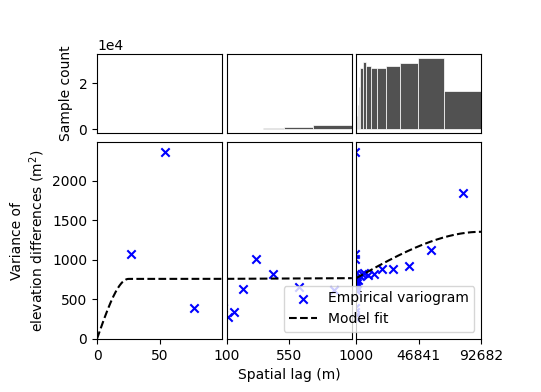

In [49]:
plt.figure()
xdem.spatialstats.plot_variogram(
    df=df_empirical_variogram,
    list_fit_fun=[xdem.spatialstats.get_variogram_model_func(df_model_params)],
    xlabel="Spatial lag (m)",
    ylabel="Variance of\nelevation differences (m$^2$)",
    xscale_range_split=[100,1000],
)

### Estimate heteroscedasticity 

In [50]:
slope, maximum_curvature = xdem.terrain.get_terrain_attribute(ref_dem, attribute=["slope", "maximum_curvature"])
errors, df_binning, error_function = xdem.spatialstats.infer_heteroscedasticity_from_stable(
    dvalues=dh, list_var=[slope, maximum_curvature], list_var_names=["slope", "maxc"], unstable_mask=glacier_outlines
)

In [51]:
zscores = dh / errors
emp_variogram, params_variogram_model, spatial_corr_function = xdem.spatialstats.infer_spatial_correlation_from_stable(
    dvalues=zscores, list_models=list_models, unstable_mask=glacier_outlines
)

c:\Users\WilsonSIRL5-MCY-E113\miniconda3\envs\xdem\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [52]:
params_variogram_model

,model,range,psill
0,spherical,6.218518,0.800772
0,spherical,92681.900024,1.058344


<Figure size 640x480 with 0 Axes>

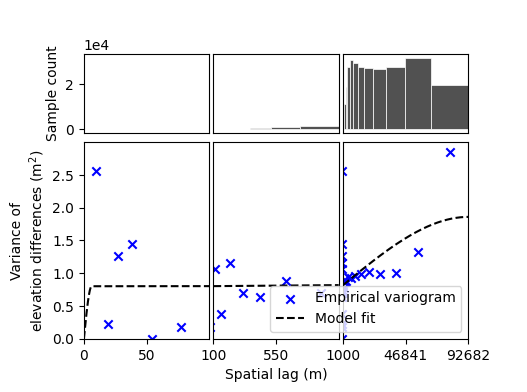

In [53]:
plt.figure()
xdem.spatialstats.plot_variogram(
    df=emp_variogram,
    list_fit_fun=[xdem.spatialstats.get_variogram_model_func(params_variogram_model)],
    xlabel="Spatial lag (m)",
    ylabel="Variance of\nelevation differences (m$^2$)",
    xscale_range_split=[100,1000],
)

#####  Spatial integration of variance on the target area

In [54]:
areas = [
    13510000., ## Caribou 
    21720000., ## Fork Beard 
    100590000., ## Highway
    14440000., ## Nakarpog 
    27133232., ## Nerutusoq 
    33903040., ## Norman 
    46728400., ## Rundle 
    29378128., ## Turner 
]

stderr_glaciers = xdem.spatialstats.spatial_error_propagation(
    areas=areas, errors=errors, params_variogram_model=params_variogram_model
)

for glacier_name, stderr_gla in [("Caribou", stderr_glaciers[0]), ("Fork Beard ", stderr_glaciers[1]), ("Highway", stderr_glaciers[2]), ("Nakarpog", stderr_glaciers[3]), ("Nerutusoq", stderr_glaciers[4]), ("Norman", stderr_glaciers[5]), ("Rundle", stderr_glaciers[6]), ("Turner", stderr_glaciers[7])]:
    print(f"The error (1-sigma) in mean elevation change for {glacier_name} is {stderr_gla:.2f} meters.")

The error (1-sigma) in mean elevation change for Caribou is 22.10 meters.
The error (1-sigma) in mean elevation change for Fork Beard  is 22.04 meters.
The error (1-sigma) in mean elevation change for Highway is 21.66 meters.
The error (1-sigma) in mean elevation change for Nakarpog is 22.09 meters.
The error (1-sigma) in mean elevation change for Nerutusoq is 22.00 meters.
The error (1-sigma) in mean elevation change for Norman is 21.95 meters.
The error (1-sigma) in mean elevation change for Rundle is 21.88 meters.
The error (1-sigma) in mean elevation change for Turner is 21.98 meters.


C:\Users\WilsonSIRL5-MCY-E113\AppData\Local\Temp\ipykernel_27476\2536995883.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


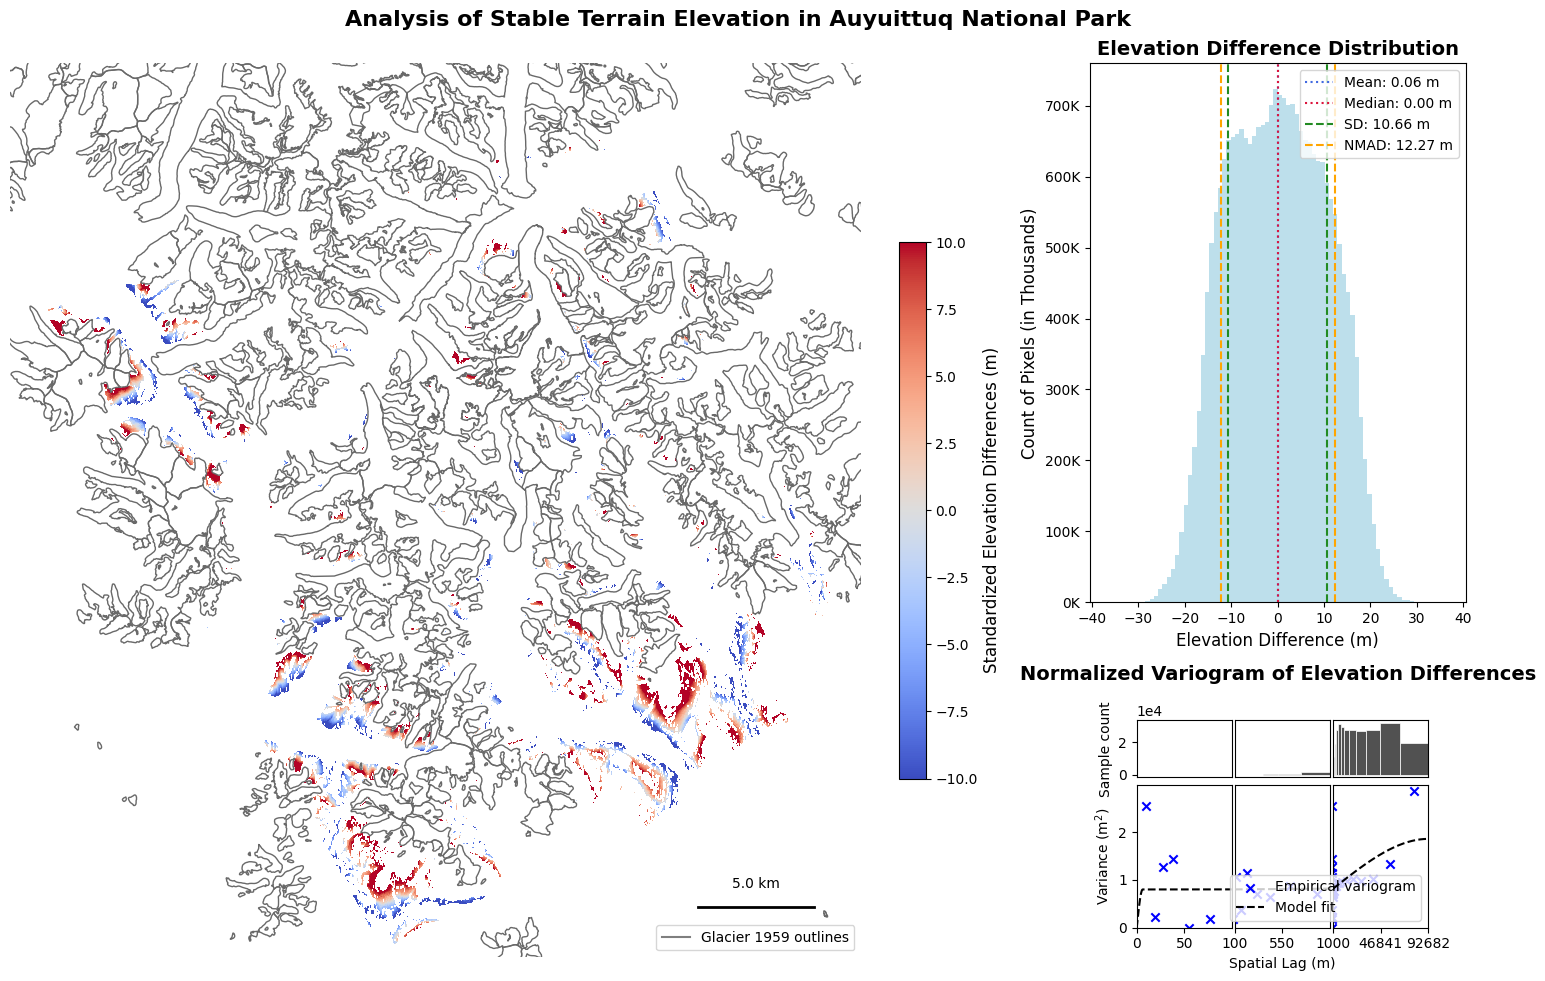

In [55]:
# Create a figure with two subplots
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], width_ratios=[2.5, 1])  # Increase width of left side for the DEM plot

# First subplot for the mean DEM with glacier outlines
ax1 = fig.add_subplot(gs[:, 0])  # Span both rows on the left column
plt_extent = [
    mean_dem.bounds.left,
    mean_dem.bounds.right,
    mean_dem.bounds.bottom,
    mean_dem.bounds.top,
]
ax1.axis('off')
glacier_outlines.ds.plot(ax=ax1, fc="none", ec="dimgray", zorder=2)
ax1.plot([], [], color="tab:gray", label="Glacier 1959 outlines")

aspect = mean_dem_float.shape[0] / mean_dem_float.shape[1] * \
         (plt_extent[1] - plt_extent[0]) / (plt_extent[3] - plt_extent[2])
im = ax1.imshow(mean_dem_float.data, cmap="coolwarm", vmin=-10, vmax=10, extent=plt_extent, aspect=aspect)

# Color bar customization
cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, shrink=0.6)
cbar.set_label("Standardized Elevation Differences (m)", fontsize=12)

# Adding a scale bar as an inset in the first subplot
scalebar_length = 5000  # Define length of the scale bar in meters (5 km)
scalebar_inset = inset_axes(ax1, width="15%", height="2%", loc="lower right", borderpad=3)
scalebar_inset.plot([0, scalebar_length], [0, 0], color='black', linewidth=2, zorder=3)
scalebar_inset.text(scalebar_length / 2, 0.1, f"{scalebar_length / 1000} km", ha='center', va='bottom', zorder=3, fontsize=10)
scalebar_inset.axis('off')
ax1.legend(loc="lower right", fontsize=10)

# Second subplot for the histogram with reduced height and improved styles
ax2 = fig.add_subplot(gs[0, 1])
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, loc: "{:,}K".format(int(x/1000))))
ax2.hist(elevation_data_cleaned, bins=80, color='lightblue', alpha=0.8)
ax2.axvline(mean_elevation, color='royalblue', linestyle='dotted', linewidth=1.5, label=f'Mean: {mean_elevation:.2f} m')
ax2.axvline(median_elevation, color='crimson', linestyle='dotted', linewidth=1.5, label=f'Median: {median_elevation:.2f} m')
ax2.axvline(mean_elevation + std_dev, color='forestgreen', linestyle='dashed', linewidth=1.5, label=f'SD: {std_dev:.2f} m')
ax2.axvline(mean_elevation - std_dev, color='forestgreen', linestyle='dashed', linewidth=1.5)
ax2.axvline(median_elevation + NMAD, color='orange', linestyle='dashed', linewidth=1.5, label=f'NMAD: {NMAD:.2f} m')
ax2.axvline(median_elevation - NMAD, color='orange', linestyle='dashed', linewidth=1.5)
ax2.set_xlabel('Elevation Difference (m)', fontsize=12)
ax2.set_ylabel('Count of Pixels (in Thousands)', fontsize=12)
ax2.legend(loc="upper right", fontsize=10)
ax2.set_title('Elevation Difference Distribution', fontsize=14, weight='bold')

# Third subplot for the variogram below the histogram with adjustments
ax3 = fig.add_subplot(gs[1, 1])
xdem.spatialstats.plot_variogram(
    df=emp_variogram,
    list_fit_fun=[xdem.spatialstats.get_variogram_model_func(params_variogram_model)],
    xlabel="Spatial Lag (m)",
    ylabel="Variance (m$^2$)",
    xscale_range_split=[100, 1000],
    ax=ax3
)
ax3.set_title('Normalized Variogram of Elevation Differences', fontsize=14, weight='bold')
ax3.grid(True, linestyle='--', alpha=0.7)

# General title for the entire figure
plt.suptitle('Analysis of Stable Terrain Elevation in Auyuittuq National Park', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()